In [2]:
import torch
import torch.nn.functional as F


In [3]:
from audio_classification_playground.vox_profile.emotion.wavlm_emotion_dim import WavLMWrapper
from audio_classification_playground.vox_profile.emotion.whisper_emotion_dim import WhisperWrapper

/workspace/audio-classification-playground/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
device = torch.device("cuda") if torch.cuda.is_available() else "cpu"

model = WhisperWrapper.from_pretrained("tiantiaf/whisper-large-v3-msp-podcast-emotion-dim").to(device)
model = model.eval()

Some weights of WhisperModel were not initialized from the model checkpoint at openai/whisper-large-v3 and are newly initialized because the shapes did not match:
- encoder.embed_positions.weight: found shape torch.Size([1500, 1280]) in the checkpoint and torch.Size([750, 1280]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [3]:
device = torch.device("cuda") if torch.cuda.is_available() else "cpu"
# Load model from Huggingface
model = WavLMWrapper.from_pretrained("tiantiaf/wavlm-large-msp-podcast-emotion-dim").to(device)
model = model.eval()

In [5]:
import librosa
import torch
import torch.nn.functional as F
SR = 16_000
WINDOW_SEC = 3.5
HOP_SEC = 1.0
BATCH_SIZE = 20
window_samples = int(WINDOW_SEC * SR)   # 56,000
hop_samples = int(HOP_SEC * SR)         # 16,000

In [6]:
audio_path = "/workspace/tmp_data/3d48c229-3505-4a40-b4d2-1e704aa0b8cc.mp3"
audio,_ = librosa.load(audio_path, sr=SR, mono=True)

In [7]:
audio.shape[0]/SR/60

59.03847708333333

In [8]:
len(windows)

NameError: name 'windows' is not defined

In [9]:
# 2. Convert to tensor
audio_t = torch.from_numpy(audio).float()
# 3. Pad so the last partial window isn't silently dropped
remainder = (len(audio_t) - window_samples) % hop_samples
if remainder != 0:
    pad_needed = hop_samples - remainder
    audio_t = F.pad(audio_t, (0, pad_needed))
# 4. Unfold into overlapping windows  →  [N, window_samples]
#    unfold(dim, size, step) returns a view — no copy
windows = audio_t.unfold(0, window_samples, hop_samples)
# 5. Batch inference
all_arousal, all_valence, all_dominance = [], [], []
for i in range(0, len(windows), BATCH_SIZE):
    batch = windows[i : i + BATCH_SIZE].to(device)
    with torch.no_grad():
        a, v, d = model(batch)
    all_arousal.append(a.cpu())
    all_valence.append(v.cpu())
    all_dominance.append(d.cpu())
arousal   = torch.cat(all_arousal).squeeze(-1).numpy()    # [N]
valence   = torch.cat(all_valence).squeeze(-1).numpy()
dominance = torch.cat(all_dominance).squeeze(-1).numpy()


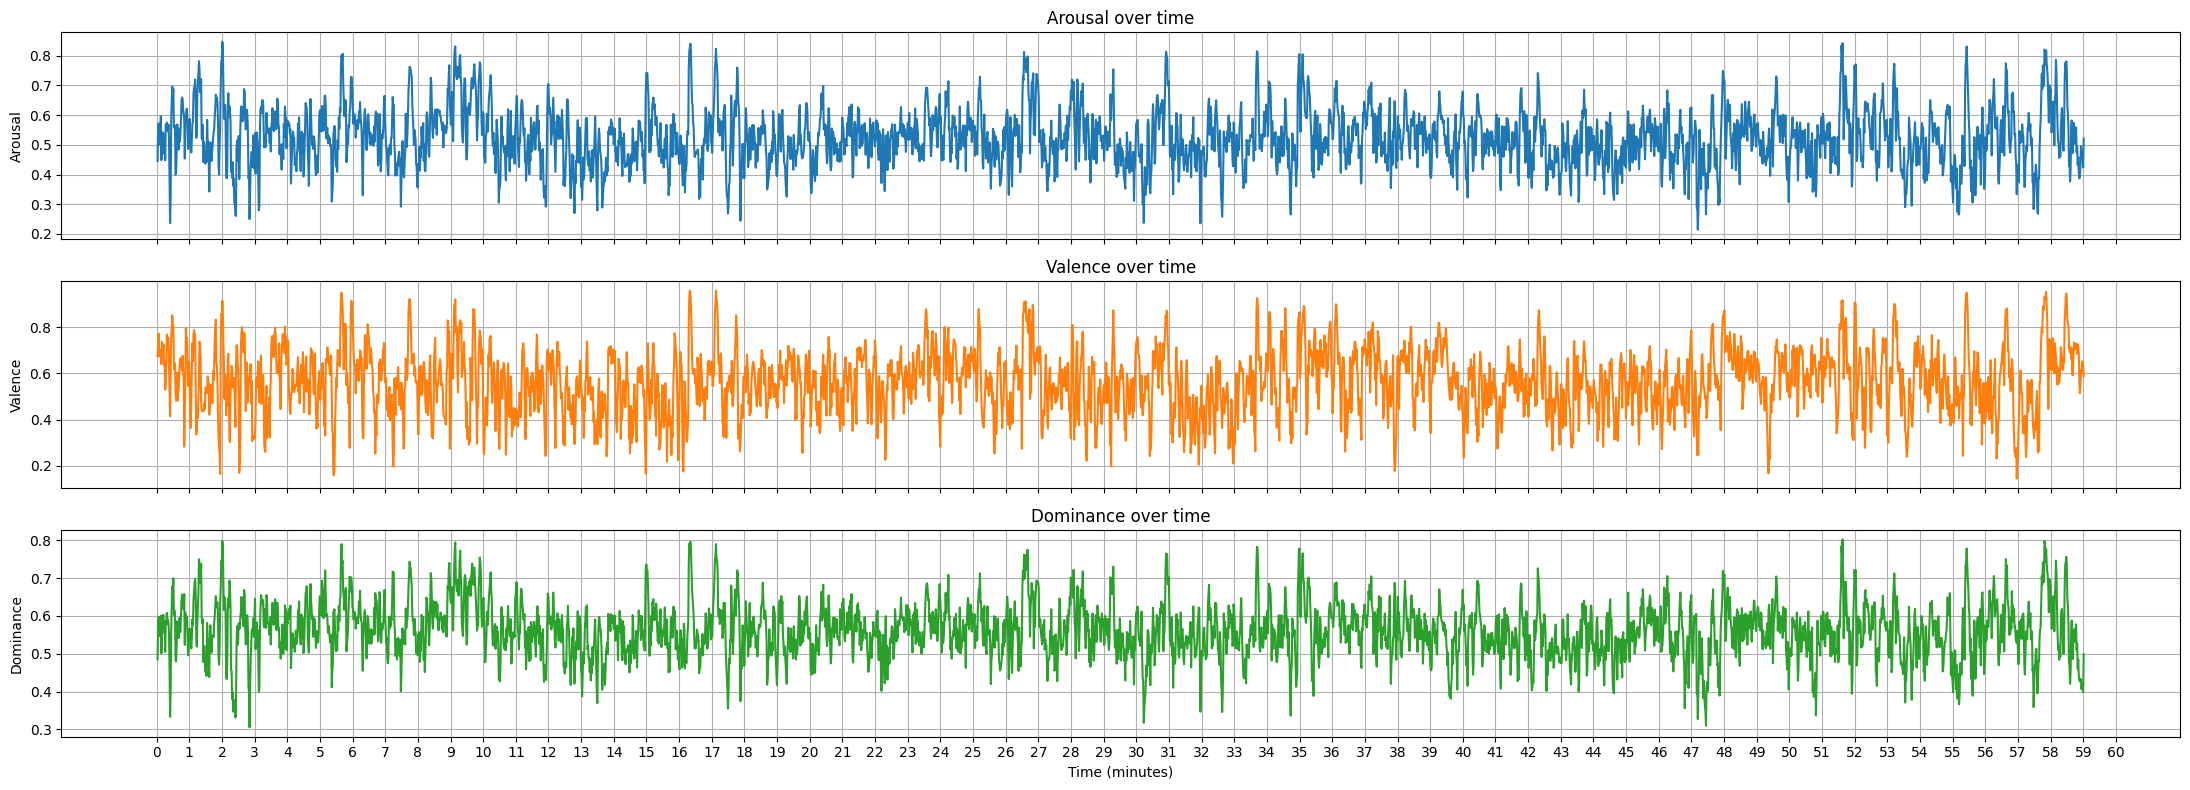

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

# Compute time axis for center of each window, in seconds first
num_windows = len(arousal)
window_centers_sec = np.arange(num_windows) * HOP_SEC + WINDOW_SEC / 2
window_centers_min = window_centers_sec / 60.0

fig, axs = plt.subplots(3, 1, figsize=(22, 8), sharex=True)  # Widens the figure more

# Set major ticks at every minute (floor to closest integer min, up to last min)
time_min_max = window_centers_min[-1]
minute_ticks = np.arange(0, time_min_max + 1, 1)
axs[-1].set_xticks(minute_ticks)

axs[0].plot(window_centers_min, arousal, label="Arousal", color="tab:blue")
axs[0].set_ylabel("Arousal")
axs[0].set_title("Arousal over time")
axs[0].grid(True)
axs[0].set_xticks(minute_ticks)
axs[0].set_xticklabels([f"{tick:.0f}" for tick in minute_ticks])

axs[1].plot(window_centers_min, valence, label="Valence", color="tab:orange")
axs[1].set_ylabel("Valence")
axs[1].set_title("Valence over time")
axs[1].grid(True)
axs[1].set_xticks(minute_ticks)
axs[1].set_xticklabels([f"{tick:.0f}" for tick in minute_ticks])

axs[2].plot(window_centers_min, dominance, label="Dominance", color="tab:green")
axs[2].set_xlabel("Time (minutes)")
axs[2].set_ylabel("Dominance")
axs[2].set_title("Dominance over time")
axs[2].grid(True)
axs[2].set_xticks(minute_ticks)
axs[2].set_xticklabels([f"{tick:.0f}" for tick in minute_ticks])

# Format the x-axis as integer minutes
axs[2].xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))

plt.tight_layout()
plt.show()

In [7]:
import sys
print(sys.executable)
print(sys.path)

/workspace/audio-classification-playground/.venv/bin/python3
['/usr/lib/python310.zip', '/usr/lib/python3.10', '/usr/lib/python3.10/lib-dynload', '', '/workspace/audio-classification-playground/.venv/lib/python3.10/site-packages', '/workspace/audio-classification-playground']


In [2]:
import sys, subprocess
result = subprocess.run(
    [sys.executable, "-m", "pip", "show", "audio-classification-playground"],
    capture_output=True, text=True
)
print(result.stdout)

In [3]:
import sys
for p in sys.path:
    print(p)

/usr/lib/python310.zip
/usr/lib/python3.10
/usr/lib/python3.10/lib-dynload

/workspace/audio-classification-playground/.venv/lib/python3.10/site-packages
/workspace/audio-classification-playground
